O Dataset inclui dados de pacientes afro americanos e tem o objetivo de indentificar diabetes

In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report




- Carregamento do DataSet

In [146]:
diab = pd.read_csv('diabetes.csv')

- Conhecendo os Dados

In [147]:
print(diab.info())
print(diab.describe())


<class 'pandas.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        403 non-null    int64  
 1   chol      402 non-null    float64
 2   stab.glu  403 non-null    int64  
 3   hdl       402 non-null    float64
 4   ratio     402 non-null    float64
 5   glyhb     390 non-null    float64
 6   location  403 non-null    str    
 7   age       403 non-null    int64  
 8   gender    403 non-null    str    
 9   height    398 non-null    float64
 10  weight    402 non-null    float64
 11  frame     391 non-null    str    
 12  bp.1s     398 non-null    float64
 13  bp.1d     398 non-null    float64
 14  bp.2s     141 non-null    float64
 15  bp.2d     141 non-null    float64
 16  waist     401 non-null    float64
 17  hip       401 non-null    float64
 18  time.ppn  400 non-null    float64
dtypes: float64(13), int64(3), str(3)
memory usage: 59.9 KB
None
                 id   

In [148]:
df = diab.copy().rename(columns={
    'id' : 'Numero indentificação',
    'chol' : 'Colesterol Total(mg/dL)',
    'stab.glu' : 'Glicose Estabilizada(mg/dL)',
    'hdl' : 'Colesterol HDL(mg/dL)',
    'ratio' : 'Razao de Colesterol',
    'glyhb' : 'Hemoglobina A1c',
    'location' : 'Localizacao',
    'age' : 'Idade',
    'gender' : 'Genero',
    'height' : 'Altura(Pol.)',
    'weight' : 'Peso(Libras)',
    'frame' : 'Biotipos',
    'bp.1s' : 'Pressão Arterial Sistolica',
    'bp.1d' : 'Pressão Arterial Diastolica',
    'bp.2s' : 'Pressão Arterial Sistolica2',
    'bp.2d' : 'Pressão Arterial Diastolica2',
    'waist' : 'Cirncunferencia da Cintura(Pol.)',
    'hip' : 'Circunferencia do Quadril(Pol.)',
    'time.ppn' : 'Tempo pos-refeicao',

})
df.head()

,Numero indentificação,Colesterol Total(mg/dL),Glicose Estabilizada(mg/dL),Colesterol HDL(mg/dL),Razao de Colesterol,Hemoglobina A1c,Localizacao,Idade,Genero,Altura(Pol.),Peso(Libras),Biotipos,Pressão Arterial Sistolica,Pressão Arterial Diastolica,Pressão Arterial Sistolica2,Pressão Arterial Diastolica2,Cirncunferencia da Cintura(Pol.),Circunferencia do Quadril(Pol.),Tempo pos-refeicao
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


3 - DATA CLEANING

Removi as colunas duplicadas e desnecessarias como tambem as linhas que estavam faltando dados, resultando em um conjunto final com 366 observações. Optei pela remoção para evitar usar valores estimados no conjunto de dados e prejudicar a acuracia do machine learning.

In [149]:
print(df.isna().sum())
print(df.shape)


Numero indentificação                 0
Colesterol Total(mg/dL)               1
Glicose Estabilizada(mg/dL)           0
Colesterol HDL(mg/dL)                 1
Razao de Colesterol                   1
Hemoglobina A1c                      13
Localizacao                           0
Idade                                 0
Genero                                0
Altura(Pol.)                          5
Peso(Libras)                          1
Biotipos                             12
Pressão Arterial Sistolica            5
Pressão Arterial Diastolica           5
Pressão Arterial Sistolica2         262
Pressão Arterial Diastolica2        262
Cirncunferencia da Cintura(Pol.)      2
Circunferencia do Quadril(Pol.)       2
Tempo pos-refeicao                    3
dtype: int64
(403, 19)


In [150]:
df = df.drop(columns = ['Pressão Arterial Diastolica2', 'Pressão Arterial Sistolica2', 'Numero indentificação', 'Tempo pos-refeicao'])
df = df.dropna()

print(df.isna().sum())
print(df.shape)
#df.head(10)

Colesterol Total(mg/dL)             0
Glicose Estabilizada(mg/dL)         0
Colesterol HDL(mg/dL)               0
Razao de Colesterol                 0
Hemoglobina A1c                     0
Localizacao                         0
Idade                               0
Genero                              0
Altura(Pol.)                        0
Peso(Libras)                        0
Biotipos                            0
Pressão Arterial Sistolica          0
Pressão Arterial Diastolica         0
Cirncunferencia da Cintura(Pol.)    0
Circunferencia do Quadril(Pol.)     0
dtype: int64
(367, 15)


4 - Análise Exploratoria

- Hipotese 1 - A incidencia de diabetes se da nas diferentes faixas etarias pode interferir na acurancia do machine learning?

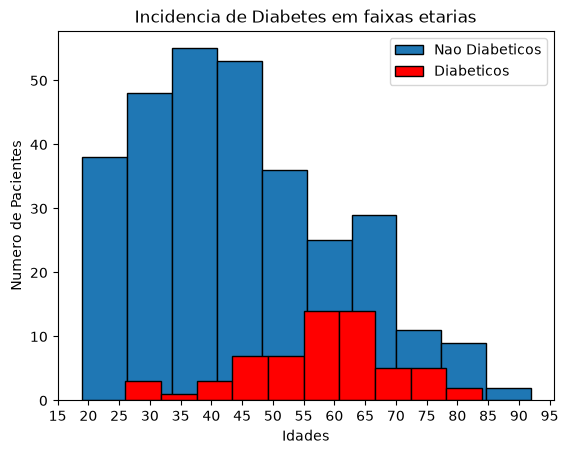

In [151]:
# Histograma Frequencia de pacientes com Diabetes por Idade


plt.hist(df['Idade'].where(df['Hemoglobina A1c'] < 6.5), alpha = 1, bins=10, label = "Nao Diabeticos", edgecolor = "black")
plt.hist(df['Idade'].where(df['Hemoglobina A1c'] >= 6.5), alpha = 1, bins=10, label = "Diabeticos", color = "red", edgecolor = "black")

plt.title("Incidencia de Diabetes em faixas etarias")
plt.xlabel("Idades")
plt.ylabel("Numero de Pacientes")
plt.xticks(range(15,96,5))
plt.legend()
plt.show()

Resultado: Fica evidente que a ocorrência de diabetes é mais comum em pacientes com idade elevada, por isso a idade pode ser um bom fator de identificação do modelo.

- Hipotese 2 - Indivíduos com níveis mais elevados de glicose estabilizada apresentam maior frequência de classificação como diabéticos?

In [152]:
df.corr(numeric_only=True).drop('Hemoglobina A1c')['Hemoglobina A1c'].sort_values(ascending=False)


Glicose Estabilizada(mg/dL)         0.741136
Razao de Colesterol                 0.354605
Idade                               0.332658
Colesterol Total(mg/dL)             0.269842
Cirncunferencia da Cintura(Pol.)    0.247412
Pressão Arterial Sistolica          0.195646
Peso(Libras)                        0.167317
Circunferencia do Quadril(Pol.)     0.152723
Altura(Pol.)                        0.051625
Pressão Arterial Diastolica         0.045604
Colesterol HDL(mg/dL)              -0.169825
Name: Hemoglobina A1c, dtype: float64

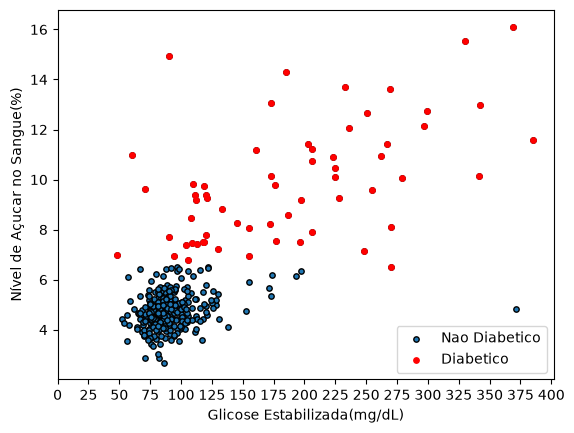

In [153]:
plt.scatter(df['Glicose Estabilizada(mg/dL)'],df['Hemoglobina A1c'], label="Nao Diabetico", s = 15, edgecolors = "black")
plt.scatter(df['Glicose Estabilizada(mg/dL)'],df['Hemoglobina A1c'].where(df['Hemoglobina A1c']>=6.5),color="red", label="Diabetico", s=15)
plt.xticks(range(0,401,25))
plt.xlabel("Glicose Estabilizada(mg/dL)")
plt.ylabel("Nível de Açucar no Sangue(%)")
plt.legend();

Resultado: Os dados demonstram que o aumento da Glicose Estabilizada está diretamente ligado à taxa de Hemoglobina A1c, o que poderia invalidar os métodos de machine learning, dando a resposta do modelo dentro dos testes. 
Clinicamente, se a glicose sobe, a A1c acompanha. Elas possuem uma relação de causa e efeito direta, por isso, usar uma métrica laboratorial do açúcar para prever outra métrica laboratorial do açúcar é redundante na medicina.

In [154]:
df = df.drop(columns = ['Glicose Estabilizada(mg/dL)'])

- Hipotese 3 - Pacientes com maior Razão de Colesterol apresentam maior frequência na classificação como diabeticos?

In [155]:
df['target'] = np.where(df['Hemoglobina A1c'] >= 6.5, 'Diabetico', 'Nao Diabetico')
cols = ['Colesterol Total(mg/dL)', 'Colesterol HDL(mg/dL)', 'Razao de Colesterol']
df[cols].describe().T.round(2)
df.groupby('target')[cols].agg(['mean']).round(2)


,Colesterol Total(mg/dL),Colesterol HDL(mg/dL),Razao de Colesterol
,mean,mean,mean
target,,,
Diabetico,229.77,44.23,5.77
Nao Diabetico,203.11,51.48,4.29


Resultado: Os dados confirmam a hipótese, demonstrando que a média da Razão de Colesterol nos pacientes diabéticos  é maior do que nos não diabéticos.

- Hipotese 4 - O Desvio Padrão dos dados pode prejudicar a aplicação do KNN


In [156]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Colesterol Total(mg/dL),367.0,207.54,43.99,78.00,179.00,204.00,229.00,443.00
Colesterol HDL(mg/dL),367.0,50.28,17.12,12.00,38.00,46.00,59.00,120.00
Razao de Colesterol,367.0,4.54,1.76,1.50,3.20,4.20,5.40,19.30
Hemoglobina A1c,367.0,5.60,2.23,2.68,4.39,4.86,5.63,16.11
Idade,367.0,46.68,16.28,19.00,34.00,45.00,60.00,92.00
Altura(Pol.),367.0,66.05,3.88,52.00,63.00,66.00,69.00,76.00
Peso(Libras),367.0,178.12,40.63,99.00,151.00,174.00,200.00,325.00
Pressão Arterial Sistolica,367.0,137.11,23.06,90.00,121.50,136.00,148.00,250.00
Pressão Arterial Diastolica,367.0,83.40,13.65,48.00,75.00,82.00,92.00,124.00
Cirncunferencia da Cintura(Pol.),367.0,37.93,5.80,26.00,33.00,37.00,41.50,56.00


A coluna do desvio padrão mostra uma disperção dos dados que pode afetar diretamente a aplicação do KNN

- Preparação pro machine learning

O metodos de machine learning usa dados numericos por isso eu preciso deixar as colunas como "Localizaçao" utilizaveis. Para isso vou utilizar o OneHotEncoder e OrdinalEncoder

In [157]:
print(df['Localizacao'].unique())
print(df['Genero'].unique())
print(df['Biotipos'].unique())

<StringArray>
['Buckingham', 'Louisa']
Length: 2, dtype: str
<StringArray>
['female', 'male']
Length: 2, dtype: str
<StringArray>
['medium', 'large', 'small']
Length: 3, dtype: str


In [158]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output = False).set_output(transform = 'pandas')
ohetransform = ohe.fit_transform(df[['Localizacao']])
df = pd.concat([df, ohetransform], axis=1).drop(columns=['Localizacao'])

ohetransform = ohe.fit_transform(df[['Genero']])
df = pd.concat([df, ohetransform], axis=1).drop(columns=['Genero'])

biotipos = ['small', 'medium', 'large']
oe = OrdinalEncoder(categories = [biotipos])
df['Biotipos'] = oe.fit_transform(df[['Biotipos']])


df.head()


,Colesterol Total(mg/dL),Colesterol HDL(mg/dL),Razao de Colesterol,Hemoglobina A1c,Idade,Altura(Pol.),Peso(Libras),Biotipos,Pressão Arterial Sistolica,Pressão Arterial Diastolica,Cirncunferencia da Cintura(Pol.),Circunferencia do Quadril(Pol.),target,Localizacao_Buckingham,Localizacao_Louisa,Genero_female,Genero_male
0,203.0,56.0,3.6,4.31,46,62.0,121.0,1.0,118.0,59.0,29.0,38.0,Nao Diabetico,1.0,0.0,1.0,0.0
1,165.0,24.0,6.9,4.44,29,64.0,218.0,2.0,112.0,68.0,46.0,48.0,Nao Diabetico,1.0,0.0,1.0,0.0
2,228.0,37.0,6.2,4.64,58,61.0,256.0,2.0,190.0,92.0,49.0,57.0,Nao Diabetico,1.0,0.0,1.0,0.0
3,78.0,12.0,6.5,4.63,67,67.0,119.0,2.0,110.0,50.0,33.0,38.0,Nao Diabetico,1.0,0.0,0.0,1.0
4,249.0,28.0,8.9,7.72,64,68.0,183.0,1.0,138.0,80.0,44.0,41.0,Diabetico,1.0,0.0,0.0,1.0


In [159]:
df['target'] = np.where(df['Hemoglobina A1c'] >= 6.5, 1, 0)
df = df.drop(columns=(['Hemoglobina A1c']))

x = df.drop(['target'], axis = 1)
y = df['target']

x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, random_state=42)

Optei pela proporção de 80% para treino e 20% para teste porque o conjunto final de dados possui um volume reduzido garantindo que o modelo tenha dados suficientes para aprender os padrões

- Aplicação do KNN

Como indentificado na hipotese 4 a disperção dos dados está muito alta pro knn ser executado de maneira satisfatoria por isso eu vou aplicar o StandartScaler para escalonar os dados

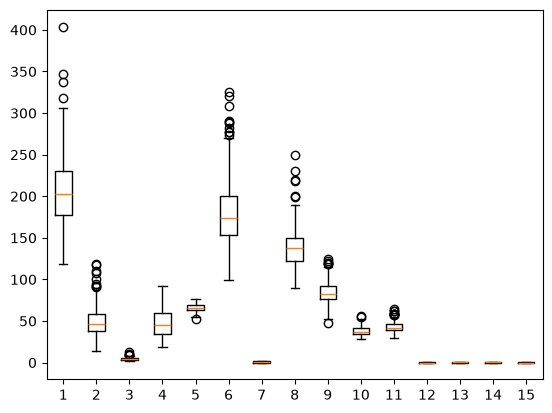

In [160]:
plt.boxplot(x_treino);


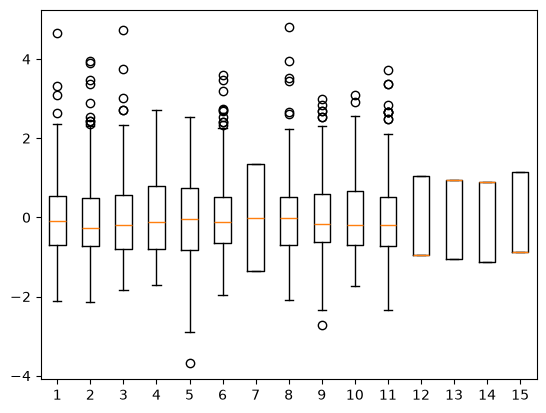

In [161]:


scaled = StandardScaler()
x_treino_scaled = scaled.fit_transform(x_treino)
x_teste_scaled = scaled.transform(x_teste)
plt.boxplot(x_treino_scaled);

In [162]:
#Determinando o paramêtro k
maiorknn = 0
for k in range(1,31,2):
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(x_treino_scaled,y_treino)
    knn_prediction = knn.predict(x_teste_scaled)
    acuracia = accuracy_score(y_teste, knn_prediction)
    if acuracia > maiorknn:
        maiorknn = acuracia
        melhork = k


print(f'O melhor parametro encontrado foi k ={melhork}')
    

O melhor parametro encontrado foi k =7


In [163]:
knn = KNeighborsClassifier(n_neighbors = 7)

knn.fit(x_treino_scaled,y_treino)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [164]:
knn_prediction = knn.predict(x_teste_scaled)

print(f'Acurácia do modelo: {accuracy_score(y_teste, knn_prediction)*100:.2f}%')

Acurácia do modelo: 87.84%


8 - RandomForest

In [165]:
rfc = RandomForestClassifier(random_state=42)

rfc.fit(x_treino,y_treino)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [166]:
rfc_prediction = rfc.predict(x_teste)
print(f'Acurácia do modelo: {accuracy_score(y_teste, rfc_prediction)*100:.2f}%')

Acurácia do modelo: 86.49%


- Avaliação dos Resultados

In [167]:
print("===================================================== KNN ==========================================================\n")
print(classification_report(y_teste, knn_prediction, target_names=["Não Diabético","Diabético"]))
print("================================================= RandomForest ==================================================\n")
print(classification_report(y_teste, rfc_prediction, target_names=["Não Diabético","Diabético"]))

===================================================== KNN ==========================================================

               precision    recall  f1-score   support

Não Diabético       0.89      0.98      0.93        64
    Diabético       0.67      0.20      0.31        10

     accuracy                           0.88        74
    macro avg       0.78      0.59      0.62        74
 weighted avg       0.86      0.88      0.85        74

================================================= RandomForest ==================================================

               precision    recall  f1-score   support

Não Diabético       0.89      0.97      0.93        64
    Diabético       0.50      0.20      0.29        10

     accuracy                           0.86        74
    macro avg       0.69      0.58      0.61        74
 weighted avg       0.83      0.86      0.84        74



O KNN se mostrou mais consistente na identificação da doença, acertando 67% dos alertas de diabetes emitidos, contra apenas 50% de acertos do Random Forest. O índice de Recall de 20% em ambos os casos é um reflexo dos poucos dados da base de teste (64 saudáveis para 10 diabéticos) e da remoção da Glicose Estabilizada.

O 

In [168]:
joblib.dump(knn, 'Modelo_KNN_Diabetes.joblib')


['Modelo_KNN_Diabetes.joblib']